## Imported the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df  = pd.read_csv('./WebTraffic_Q1_2025.csv')
df

,VisitDate,SessionDuration,PageViews,ReferralSource,DeviceType,Platform,BounceRate,Conversions
0,2025-03-17,140.78,3.0,Referral,Tablet,Windows,88.24,1
1,2025-01-03,903.04,3.0,Paid Search,Tablet,Windows,48.78,0
2,2025-02-25,395.02,5.0,Social Media,Mobile,macOS,51.13,0
3,2025-01-29,273.88,6.0,Referral,Desktop,macOS,60.36,0
4,2025-03-23,50.89,5.0,Organic Search,Mobile,Linux,88.83,1
...,...,...,...,...,...,...,...,...
595,2025-02-19,192.71,4.0,Organic Search,Mobile,Linux,58.28,0
596,2025-03-15,330.39,3.0,Social Media,Desktop,iOS,58.24,0
597,2025-01-14,56.74,6.0,Organic Search,Mobile,macOS,26.26,0
598,2025-01-14,64.07,4.0,Social Media,Mobile,macOS,49.26,0


## Find the null values & filled them with mean

In [4]:
session_duration_mean =df["SessionDuration"].mean()
df["SessionDuration"]=df["SessionDuration"].fillna(session_duration_mean)
page_views_mean =df["PageViews"].mean()
df["PageViews"]=df["PageViews"].fillna(page_views_mean)
df.isnull().sum()


VisitDate          0
SessionDuration    0
PageViews          0
ReferralSource     0
DeviceType         0
Platform           0
BounceRate         0
Conversions        0
dtype: int64

## Create new columns

In [5]:
df["VisitDate"] = pd.to_datetime(df["VisitDate"])
df["Month"] = df["VisitDate"].dt.month
df["dayOfWeek"] = df["VisitDate"].dt.day_name()
df["weekNumber"] = df["VisitDate"].dt.weekday

## Traffic Trend Analysis

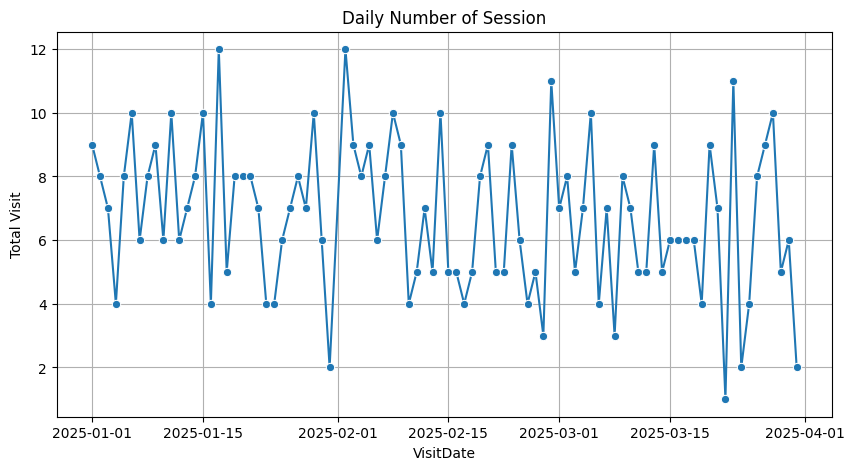

In [6]:
total_visit=df.groupby("VisitDate")["PageViews"].size().to_frame(name="Total Visit").reset_index()
plt.figure(figsize=(10,5)) 
sns.lineplot(x="VisitDate",y="Total Visit",data=total_visit,marker="o")
plt.title("Daily Number of Session")
plt.grid(True,"both","both")


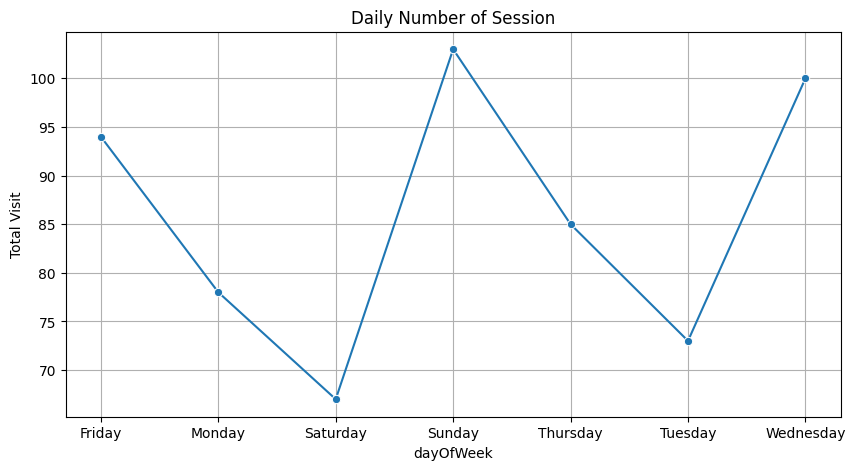

In [7]:
total_visit = df.groupby("dayOfWeek")["PageViews"].size().to_frame(name="Total Visit")
plt.figure(figsize=(10,5)) 
sns.lineplot(x="dayOfWeek",y="Total Visit",data=total_visit,marker="o")
plt.title("Daily Number of Session")
plt.grid(True,"both","both")

## User Engagement Analysis

In [8]:
df["SessionDuration"].mean()
avg_page_per_session = df.groupby("SessionDuration")["PageViews"].sum().mean()
avg_page_per_session

np.float64(5.053658367851677)

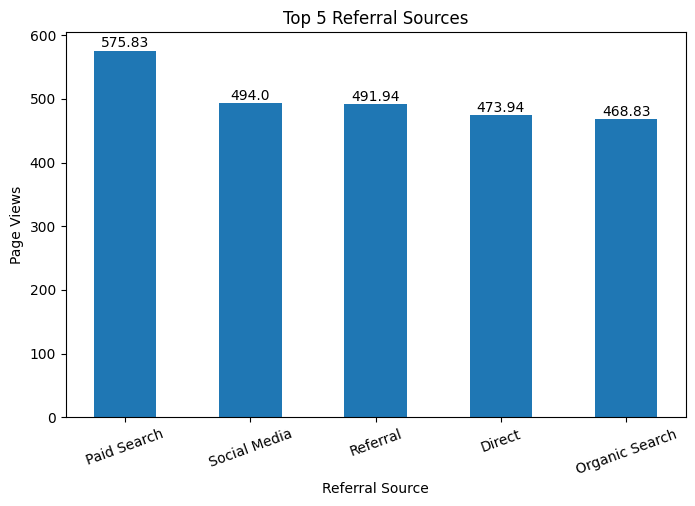

In [9]:
top_five_referral_sources = df.groupby("ReferralSource")["PageViews"].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,5))

plt.bar(
    top_five_referral_sources.index,
    top_five_referral_sources.values,
    width=0.5
)
for source, views in zip(top_five_referral_sources.index,top_five_referral_sources.values):
    plt.text(source,views+5,round(views,2),ha="center")
plt.title("Top 5 Referral Sources")
plt.xlabel("Referral Source")
plt.ylabel("Page Views")  
plt.xticks(rotation=20)

plt.show()

### Conversion Analysis

In [10]:
overall_conversion_rate=df["Conversions"].sum()/df["SessionDuration"].size
overall_conversion_rate

np.float64(0.14333333333333334)

([<matplotlib.patches.Wedge at 0x1d888372720>,
 [Text(-0.6069445164599113, 0.9173975986120984, 'Direct'),
  Text(-1.0736834018336716, -0.2391734781008849, 'Email'),
  Text(-0.3551687107756965, -1.0410836598880657, 'Organic Search'),
  Text(0.6069448153859595, -0.9173974008444236, 'Paid Search'),
  Text(1.0934010410221413, 0.12030861769506795, 'Referral'),
  Text(0.4669023868890871, 0.9959930527454866, 'Social Media')],
 [Text(-0.33106064534176977, 0.5003986901520536, '18.60%'),
  Text(-0.5856454919092754, -0.13045826078230083, '19.77%'),
  Text(-0.19372838769583442, -0.5678638144843995, '12.79%'),
  Text(0.3310608083923415, -0.5003985822787764, '16.28%'),
  Text(0.5964005678302587, 0.06562288237912797, '18.60%'),
  Text(0.25467402921222926, 0.5432689378611744, '13.95%')])

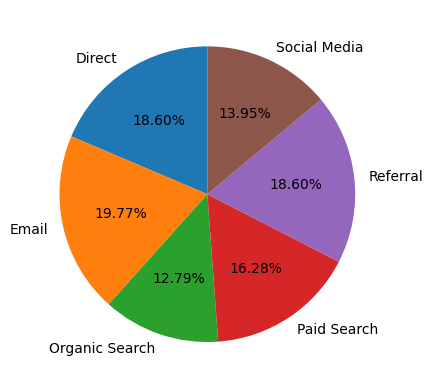

In [11]:
conversion_rate_per_resource = df.groupby("ReferralSource")["Conversions"].sum()
plt.pie(conversion_rate_per_resource.values,labels=conversion_rate_per_resource.index,startangle=90,autopct="%.2f%%")

## Device & Platform Insights 

In [12]:
df.groupby("DeviceType")["SessionDuration"].mean()

DeviceType
Desktop    315.972775
Mobile     311.334046
Tablet     304.953981
Name: SessionDuration, dtype: float64

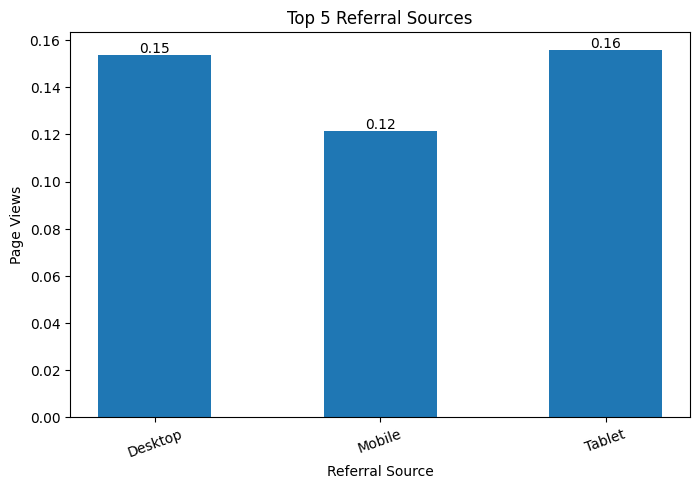

In [13]:
conversion_rate_by_device_type=df.groupby("DeviceType")["Conversions"].mean()
plt.figure(figsize=(8,5))

plt.bar(
    conversion_rate_by_device_type.index,
    conversion_rate_by_device_type.values,
    width=0.5
)
for source, views in zip(conversion_rate_by_device_type.index,conversion_rate_by_device_type.values):
    plt.text(source,views+0.001,round(views,2),ha="center")
plt.title("Top 5 Referral Sources")
plt.xlabel("Referral Source")
plt.ylabel("Page Views")  
plt.xticks(rotation=20)

plt.show()

## Bounce Rate Pattern

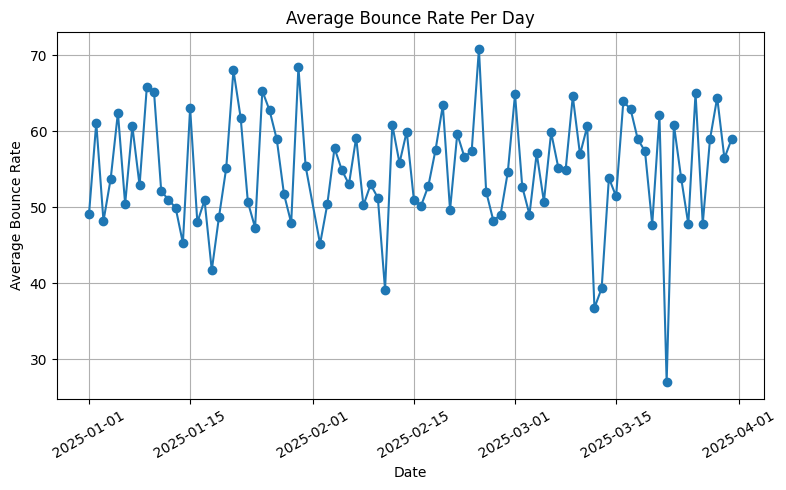

In [14]:
avg_bounce_rate_per_day=df.groupby("VisitDate")["BounceRate"].mean().sort_index()
plt.figure(figsize=(8,5))
plt.plot(avg_bounce_rate_per_day.index,avg_bounce_rate_per_day.values,marker="o")
plt.xlabel("Date")
plt.ylabel("Average Bounce Rate")
plt.title("Average Bounce Rate Per Day")
plt.xticks(rotation=30)
plt.grid(True)
plt.tight_layout()


In [15]:
df2=df.groupby("VisitDate")["BounceRate"].mean().loc[lambda x:x>70]
df2

VisitDate
2025-02-24    70.805
Name: BounceRate, dtype: float64